In [9]:
import pandas as pd

df = pd.read_csv("../../data/results/merged_results.csv")
df

,conv_id,model_id,request,hypothesis,reference,context,score_1,score_2,ot_score,global_score,bertscore_recall_ref,bertscore_f1_ref,bertscore_precision_ctx,bertscore_f1_ctx,hyp_len,ref_len,ctx_len
0,0,GPT-4o,d'où vient la phrase great scott,"La phrase **""Great Scott!""** est une exclamati...","L'origine de l'expression ""Great Scott"" n'est ...","L'origine exacte de l'expression ""Great Scott!...",0.687285,20.666667,124.305556,114.666667,0.741804,0.602208,0.643321,0.722645,294,9,76
1,1,Le Chat,d'où vient la phrase great scott,"La phrase ""Great Scott!"" est une exclamation q...","L'origine de l'expression ""Great Scott"" n'est ...","L'origine exacte de l'expression ""Great Scott!...",63.636364,19.480519,41.025641,51.948052,0.814957,0.690684,0.686105,0.716543,111,9,76
2,2,DeepSeek,d'où vient la phrase great scott,"L'expression **""Great Scott !""** est une inter...","L'origine de l'expression ""Great Scott"" n'est ...","L'origine exacte de l'expression ""Great Scott!...",7.981221,16.535433,101.886792,94.488189,0.726123,0.616126,0.684916,0.759559,218,9,76
3,3,GPT-4o,Quand est-ce que les Lakers ont fait les playo...,Les Los Angeles Lakers ont fait les playoffs p...,Les Los Angeles Lakers ont participés aux play...,Les Los Angeles Lakers ont participés aux play...,3.333333,8.823529,164.705882,173.529412,0.815075,0.716053,0.711887,0.764960,96,17,31
4,4,Le Chat,Quand est-ce que les Lakers ont fait les playo...,L'équipe des Lakers de Los Angeles a participé...,Les Los Angeles Lakers ont participés aux play...,Les Los Angeles Lakers ont participés aux play...,81.250000,35.294118,45.454545,35.294118,0.826142,0.824624,0.803636,0.751235,16,17,31
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
70,70,Le Chat,quand a été vue pour la dernière fois la comèt...,La comète de Halley a été observée pour la der...,La comète de Halley a été vue pour la dernière...,La comète de Halley a été vue pour la dernière...,35.483871,13.636364,55.000000,59.090909,0.932269,0.847013,0.887929,0.881096,31,13,31
71,71,DeepSeek,quand a été vue pour la dernière fois la comèt...,La comète de Halley a été vue pour la dernière...,La comète de Halley a été vue pour la dernière...,La comète de Halley a été vue pour la dernière...,7.500000,20.689655,42.857143,62.068966,0.895219,0.743113,0.704117,0.745198,42,13,31
72,72,GPT-4o,nommez un pays voisin de l'inde qui est une ré...,Un pays voisin de l’Inde qui est une républiqu...,"Le Pakistan, le Népal, le Bangladesh, la Chine...",L'Inde possède des frontières terrestres ou ma...,30.769231,5.263158,44.444444,42.105263,0.702782,0.718767,0.717952,0.700311,26,30,43
73,73,Le Chat,nommez un pays voisin de l'inde qui est une ré...,Le Népal est un pays voisin de l'Inde qui est ...,"Le Pakistan, le Népal, le Bangladesh, la Chine...",L'Inde possède des frontières terrestres ou ma...,16.666667,14.285714,0.000000,14.285714,0.728384,0.778786,0.755587,0.706643,12,30,43


In [11]:
%pip install scipy

  Using cached scipy-1.16.0-cp313-cp313-win_amd64.whl.metadata (60 kB)
Using cached scipy-1.16.0-cp313-cp313-win_amd64.whl (38.4 MB)
Note: you may need to restart the kernel to use updated packages.



📊 Matrice de corrélation :
                         score_1  score_2  ot_score  bertscore_recall_ref  \
score_1                    1.000    0.213    -0.180                 0.046   
score_2                    0.213    1.000     0.006                -0.022   
ot_score                  -0.180    0.006     1.000                -0.243   
bertscore_recall_ref       0.046   -0.022    -0.243                 1.000   
bertscore_precision_ctx    0.123    0.230    -0.409                 0.526   
hyp_len                   -0.266   -0.175     0.304                -0.360   
ref_len                   -0.008    0.194    -0.038                -0.174   
ctx_len                   -0.090   -0.068    -0.100                -0.052   

                         bertscore_precision_ctx  hyp_len  ref_len  ctx_len  
score_1                                    0.123   -0.266   -0.008   -0.090  
score_2                                    0.230   -0.175    0.194   -0.068  
ot_score                                  -0

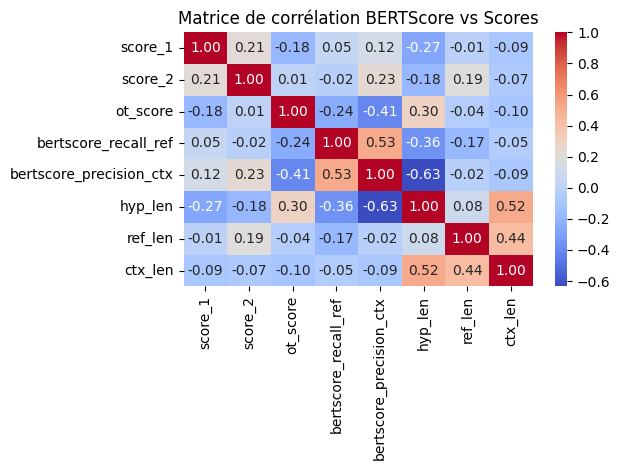

In [13]:
import seaborn as sns
import matplotlib.pyplot as plt

# Sélectionner les colonnes concernées
cols = [
    "score_1",
    "score_2",
    "ot_score",
#    "global_score",
    "bertscore_recall_ref",
#    "bertscore_f1_ref",
    "bertscore_precision_ctx",
#    "bertscore_f1_ctx",
    "hyp_len",
    "ref_len",
    "ctx_len"
]

corr_matrix = df[cols].corr()

# Afficher la matrice
print("\n📊 Matrice de corrélation :")
print(corr_matrix.round(3))

# (Optionnel) Heatmap
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Matrice de corrélation BERTScore vs Scores")
plt.tight_layout()
plt.show()


In [ ]:
df.groupby("model_id")["ot_score"].describe().sort_values("mean")

,count,mean,std,min,25%,50%,75%,max
model_id,,,,,,,,
Le Chat,25.0,64.596872,89.443338,0.000000,0.000000,41.025641,88.888889,300.000000
GPT-4o,25.0,92.744918,90.060687,0.000000,47.933884,70.000000,113.461538,456.250000
DeepSeek,25.0,153.179034,163.014838,28.169014,95.000000,126.470588,160.526316,868.421053


In [ ]:
df.groupby("model_id")["global_score"].describe().sort_values("mean")

,count,mean,std,min,25%,50%,75%,max
model_id,,,,,,,,
Le Chat,25.0,72.246126,86.536787,0.000000,9.523810,51.948052,75.000000,305.882353
GPT-4o,25.0,103.631093,104.861888,12.244898,49.019608,72.222222,114.666667,535.714286
DeepSeek,25.0,146.686927,130.764383,29.166667,94.488189,125.581395,166.666667,687.500000


In [ ]:
df.groupby("request")["score"].describe().sort_values("mean")

,count,mean,std,min,25%,50%,75%,max
request,,,,,,,,
comment s'appellent les sept continents du monde,3.0,1.960784,3.396178,0.000000,0.000000,0.000000,2.941176,5.882353
qui joue sam dans le seigneur des anneaux,3.0,4.690016,0.755032,4.166667,4.257246,4.347826,4.951691,5.555556
Quand a eu lieu la guerre de sept ans ?,3.0,5.117679,6.125440,0.000000,1.724138,3.448276,7.676519,11.904762
Quel est l'immeuble le plus haut des États-Unis ?,3.0,5.767764,1.728398,4.347826,4.805492,5.263158,6.477733,7.692308
d'où part le Danube et jusqu'ou va-t'il,3.0,5.812748,4.178362,2.564103,3.455964,4.347826,7.437071,10.526316
Dans combien d'états s'étendent les Montagnes Rocheuses ?,3.0,6.349206,3.636965,2.380952,4.761905,7.142857,8.333333,9.523810
qui a le plus de followers sur instagram,3.0,6.474155,4.709427,2.739726,3.828879,4.918033,8.341369,11.764706
quelles sont les dimensions d'une feuille de papier,3.0,8.346867,2.437807,5.714286,7.257143,8.800000,9.663158,10.526316
où va se dérouler la coupe du monde,3.0,9.525463,7.909988,1.388889,5.694444,10.000000,13.593750,17.187500


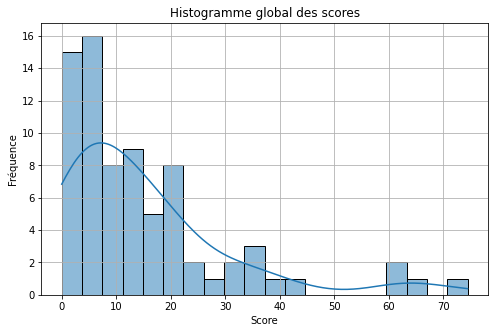

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 5))
sns.histplot(df['score'], bins=20, kde=True)
plt.title("Histogramme global des scores")
plt.xlabel("Score")
plt.ylabel("Fréquence")
plt.grid(True)
plt.show()

In [ ]:
df['nb_mots'] = df['hypothesis'].str.split().str.len()
correlation = df['nb_mots'].corr(df['ot_score'])
print(f"Corrélation (nombre de mots vs score) : {correlation:.3f}")

Corrélation (nombre de mots vs score) : 0.304


In [ ]:
df.groupby("model_id")["nb_mots"].describe().sort_values("mean")

,count,mean,std,min,25%,50%,75%,max
model_id,,,,,,,,
Le Chat,25.0,42.64,33.647536,10.0,24.0,34.0,57.0,158.0
GPT-4o,25.0,111.36,74.322989,26.0,60.0,96.0,127.0,332.0
DeepSeek,25.0,130.72,73.378312,42.0,79.0,102.0,175.0,340.0


In [ ]:
df['nb_mots_ref'] = df['reference'].str.split().str.len()
df['nb_mots_ref'].describe()

count    75.00000
mean     17.32000
std       6.82634
min       9.00000
25%      12.00000
50%      16.00000
75%      21.00000
max      32.00000
Name: nb_mots_ref, dtype: float64